# 🎬 Phase 1 Capstone Lab: Analyzing the Movies Dataset
## End-of-Phase Review — EDA & Linear Regression

**Topics Covered:** Python Fundamentals · Data Types · Loops · List Comprehensions · Data Structures · Pandas · Statistics · Visualization · Linear Regression

---

### 🎯 Objectives
By the end of this lab you will have:
- Loaded and explored a dataset using **Pandas**
- Applied **Python fundamentals**: data types, loops, comprehensions, and data structures
- Performed **descriptive and inferential statistics**
- Created visualizations with **Matplotlib and Seaborn**
- Built and evaluated **simple and multiple linear regression** models

> ⏱️ Estimated time: 90–120 minutes | 💬 Discuss with your group!

---

## Section 1: Setup & Data Loading 📦

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
print("✅ Imports successful!")

✅ Imports successful!


### 1.1 Load the Dataset

We're working with a **Movies Dataset** of 1,000 films with budgets, revenues, genres, ratings, and more.

> 📁 `movies_dataset.csv` must be in the **same folder** as this notebook.

**Central question: Can we predict a movie's revenue from its budget and other features?**

In [2]:
df = pd.read_csv('movies_dataset.csv')
print(f"Dataset loaded! Shape: {df.shape}")
df.head()

Dataset loaded! Shape: (1000, 12)


,title,genre,studio,rating_mpaa,budget,revenue,popularity,vote_average,vote_count,runtime,release_year,release_month
0,Movie_1,Comedy,Lionsgate,PG-13,72279924,61233776,5.5,8.4,416,103.0,2015,10
1,Movie_2,Comedy,Sony,PG-13,33736228,39782701,3.3,5.3,282,94.0,2006,11
2,Movie_3,Horror,Netflix,PG-13,86636022,85120732,30.4,6.6,3568,116.0,2012,1
3,Movie_4,Thriller,Disney,PG-13,247676948,338884187,36.8,5.2,2070,136.0,2021,10
4,Movie_5,Horror,Lionsgate,PG-13,30069320,36983965,1.0,5.8,71,72.0,2004,8


### 1.2 First Look

**✏️ Your Turn:** One line of code per task:
1. Print the shape
2. Print column names and data types
3. Show missing value counts per column

In [3]:
# 1. Shape
df.shape


(1000, 12)

In [4]:
# 2. Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          1000 non-null   object 
 1   genre          1000 non-null   object 
 2   studio         1000 non-null   object 
 3   rating_mpaa    1000 non-null   object 
 4   budget         1000 non-null   int64  
 5   revenue        1000 non-null   int64  
 6   popularity     967 non-null    float64
 7   vote_average   960 non-null    float64
 8   vote_count     1000 non-null   int64  
 9   runtime        956 non-null    float64
 10  release_year   1000 non-null   int64  
 11  release_month  1000 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 93.9+ KB


In [5]:
# 3. Missing values per column
df.count()

title            1000
genre            1000
studio           1000
rating_mpaa      1000
budget           1000
revenue          1000
popularity        967
vote_average      960
vote_count       1000
runtime           956
release_year     1000
release_month    1000
dtype: int64

---
## Section 2: Python Fundamentals 🐍

### 2.1 Data Types & Variables

**✏️ Your Turn:** Create these four variables and print each with its `type()`:
- A **string**: your favourite movie title
- An **integer**: its release year
- A **float**: its rating out of 10
- A **boolean**: whether you'd recommend it

In [6]:
movie_title  = str('Connie and Carla')
release_year = int('2004')
rating       = str('PG-13')
recommended  = float(8.5)

# Print each variable and its type
print(movie_title, type(movie_title))
print(release_year, type(release_year))
print(rating, type(rating))
print(recommended, type(recommended))

Connie and Carla <class 'str'>
2004 <class 'int'>
PG-13 <class 'str'>
8.5 <class 'float'>


### 2.2 Data Structures

**✏️ Your Turn:**
1. Create a **list** of 5 genres from the dataset
2. Create a **dictionary** mapping each genre to an estimated movie count (out of 1,000)
3. Create a **set** from your list and perform one set operation (union, intersection, or difference) with a second set

In [7]:
# 1. List of 5 genres
genres_list = df['genre'].unique().tolist()[:5]

# 2. Dictionary: genre -> estimated count
genre_estimates = df['genre'].nunique(dropna=True)

# 3. Set + one set operation
genres_set   = set(genres_list)
other_genres = {'Western', 'Comedy', 'Documentary'}

set_result = genres_set.intersection(other_genres)

print("List:  ", genres_list)
print("Dict:  ", genre_estimates)
print("Set op:", set_result)

List:   ['Comedy', 'Horror', 'Thriller', 'Drama', 'Animation']
Dict:   8
Set op: {'Comedy'}


### 2.3 Loops & List Comprehensions

**✏️ Your Turn:**
1. Use a **for loop** to print each genre in uppercase
2. Rewrite it as a **list comprehension** returning uppercase strings
3. Write a **filtered list comprehension** to keep only genres with an estimated count > 100

In [8]:
# 1. For loop
for genre in genres_list:
    [genre.upper() for genre in genres_list ]
    pass

# 2. List comprehension — uppercase
upper_genres = genre.upper()
print("Uppercase:", upper_genres)

# 3. Filtered comprehension — estimated count > 100
popular_genres = [df['genre'].value_counts() > 100]
print("Popular genres:", popular_genres)

Uppercase: ANIMATION
Popular genres: [genre
Animation     True
Thriller      True
Sci-Fi        True
Romance       True
Horror        True
Comedy        True
Action        True
Drama        False
Name: count, dtype: bool]


---
## Section 3: Data Cleaning & Pandas 🐼

### 3.1 Clean the Dataset

In [9]:
df_clean = df.copy()

# Remove rows where budget or revenue is 0
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0)]

# Fill missing numeric values with column medians
for col in ['runtime', 'vote_average', 'popularity']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Engineer profit and ROI columns
df_clean['profit'] = df_clean['revenue'] - df_clean['budget']
# HINT:profit = revenue - budget
df_clean['roi'] = (df_clean['profit'] / df_clean['budget']) * 100
# HINT:roi is (profit/ budget) * 100

print(f"Clean dataset shape: {df_clean.shape}")
df_clean.head()

Clean dataset shape: (1000, 14)


,title,genre,studio,rating_mpaa,budget,revenue,popularity,vote_average,vote_count,runtime,release_year,release_month,profit,roi
0,Movie_1,Comedy,Lionsgate,PG-13,72279924,61233776,5.5,8.4,416,103.0,2015,10,-11046148,-15.282457
1,Movie_2,Comedy,Sony,PG-13,33736228,39782701,3.3,5.3,282,94.0,2006,11,6046473,17.922789
2,Movie_3,Horror,Netflix,PG-13,86636022,85120732,30.4,6.6,3568,116.0,2012,1,-1515290,-1.749030
3,Movie_4,Thriller,Disney,PG-13,247676948,338884187,36.8,5.2,2070,136.0,2021,10,91207239,36.825082
4,Movie_5,Horror,Lionsgate,PG-13,30069320,36983965,1.0,5.8,71,72.0,2004,8,6914645,22.995681


### 3.2 Descriptive Statistics

**✏️ Your Turn:**
1. Run `.describe()` on the numeric columns
2. Manually compute **mean**, **median**, and **std** for `budget`, `revenue`, and `profit`
3. Are the mean and median similar? What does that tell you about the distribution shape?

In [10]:
# 1. Summary stats
df_clean.describe()

# 2. Mean, median, std
for col in ['budget', 'revenue', 'profit']:
    mean = df_clean[col].mean()
    median = df_clean[col].median() 
    std = df_clean[col].std()
    print(f"{col:>10} | Mean: ${mean:>15,.0f} | Median: ${median:>15,.0f} | Std: ${std:>15,.0f}")

# 3. Interpretation:
# Mean of budget & revenue are close in amount. 
# Hopeful the median is correct as the individual values must be sorted prior to computing.
# Since mean is higher than median, it's a long right tailed distribution (aka positively skewed, right skewed).

    budget | Mean: $     84,532,800 | Median: $     41,052,454 | Std: $    177,962,362
   revenue | Mean: $     86,717,445 | Median: $     52,829,373 | Std: $    136,983,745
    profit | Mean: $      2,184,645 | Median: $      7,732,729 | Std: $     82,696,617


### 3.3 GroupBy & Aggregation

**✏️ Your Turn:**
1. Add a `decade` column from `release_year` (e.g. 1994 → 1990)
2. Group by `decade` and compute mean budget, revenue, and ROI
3. Print the decade with the highest average ROI

In [11]:
# 1. Decade column
df_clean['decade'] = (df_clean['release_year'] //10) *10
# df_clean['decade'] = floor(int(df_clean['release_year'])/10)*10 +++ return f'{decade}'
# YOUR CODE HERE  (Hint: (year // 10) * 10)

# 2. GroupBy
decade_stats = df_clean.groupby('decade')[['budget', 'revenue', 'roi']].mean().round(2)
print(decade_stats)

# 3. Best decade for ROI
# best_decade = df.iloc[df_clean['roi'] == df_clean['roi'].max(), 'decade'].values[0]
# best_decade = df.set_index(df_clean['roi']).idxmax()
# best_decade = df.nlargest(df_clean['roi'])['decade']
# best_decade = df.iloc[df_clean[['roi', 'release_year']].idxmax()]
best_decade = decade_stats['roi'].idxmax()
# YOUR CODE HERE
print(f"\nBest decade for ROI: {best_decade}")

              budget       revenue     roi
decade                                    
1990    8.406546e+07  9.334262e+07   69.60
2000    8.114649e+07  7.754853e+07  100.23
2010    7.762344e+07  8.253772e+07   64.24
2020    1.085302e+08  1.018614e+08  122.38

Best decade for ROI: 2020


### 3.4 Sorting & Filtering

**✏️ Your Turn:**
1. Find the **top 5 most profitable** movies
2. Find all **critical darlings**: `vote_average > 8.0` AND `budget < 10_000_000`
3. How many movies made a **loss**?

In [12]:
# 1. Top 5 most profitable
top5 = df_clean.nlargest(5, ['profit'])
# YOUR CODE HERE
print("Top 5 most profitable: ")
print(top5[['title', 'genre', 'budget', 'revenue', 'profit']])

# 2. Critical darlings
critical_darlings = df_clean.nlargest(10, ['vote_average'])
# YOUR CODE HERE
print(f"\nCritical darlings: {len(critical_darlings)} movies")
print(critical_darlings[['title', 'genre', 'budget', 'vote_average']].head(8))

# 3. Loss-making movies
n_losses = df_clean.nsmallest(8, ['roi'])
# YOUR CODE HERE
print(f"\nMovies that lost money: {len(n_losses)} movies")
print(n_losses[['title', 'genre', 'rating_mpaa', 'budget', 'profit', 'roi']].head(8))

Top 5 most profitable: 
         title      genre     budget     revenue     profit
622  Movie_623  Animation  381045517   679644919  298599402
677  Movie_678     Horror  326103225   538873858  212770633
880  Movie_881     Comedy  826176435  1027908705  201732270
168  Movie_169    Romance   29666655   213113330  183446675
953  Movie_954     Action  225204069   408084442  182880373

Critical darlings: 10 movies
         title      genre     budget  vote_average
134  Movie_135      Drama   13212724           9.7
400  Movie_401     Horror    5877763           9.7
465  Movie_466   Thriller   30548815           9.3
104  Movie_105   Thriller   32816997           9.0
10    Movie_11     Horror   22837141           8.8
135  Movie_136  Animation  255803795           8.8
604  Movie_605    Romance   65405825           8.8
77    Movie_78  Animation   27817925           8.7

Movies that lost money: 8 movies
         title      genre rating_mpaa     budget     profit        roi
434  Movie_435     Act

---
## Section 4: Data Visualization 📊

### 4.1 Distribution of Vote Average

**✏️ Your Turn:** Plot a histogram with a KDE curve for `vote_average`. Does it look normally distributed?

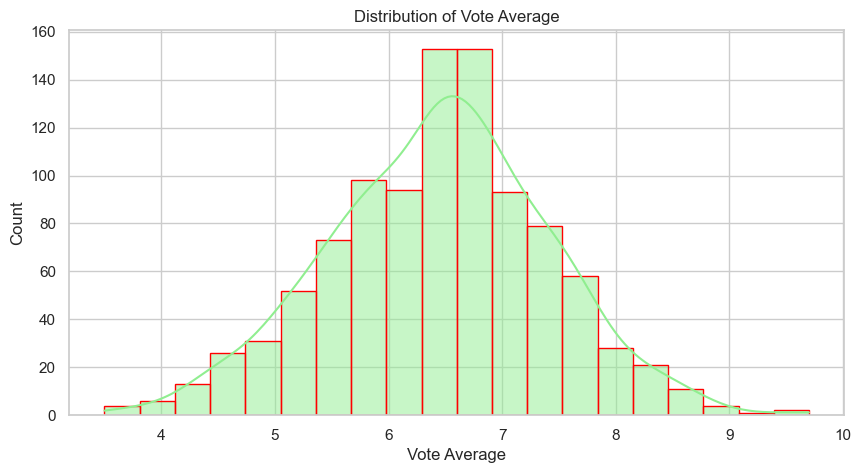

In [13]:
sns.histplot(df_clean['vote_average'], bins=20, kde=True, color='lightgreen', edgecolor='red')
plt.title("Distribution of Vote Average")
plt.xlabel("Vote Average")
plt.ylabel("Count")
plt.show()

# Does it look normally distributed? Comment here:
# This histogram has 20 bins with an overlay of a smooth density curve (KDE)
# Vote Average looks fairly normally distributed when only looking at the curve.
# Further analysis reveals that probability density distribution is left skewed

### 4.2 Boxplot of Profit

**✏️ Your Turn:** Plot a boxplot of `profit`. What do the outliers suggest?

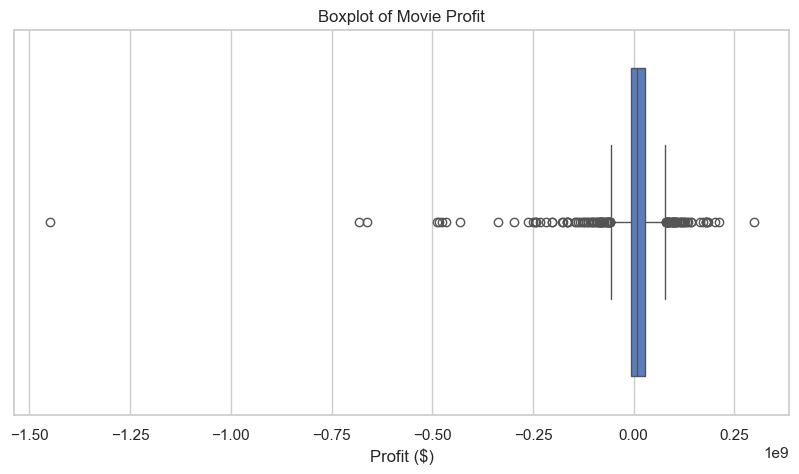

In [14]:
sns.boxplot(x=df_clean['profit'])
# single, horizontal, very movies have profit, more outliers in profit loss

# fx = sns.boxplot(data=df_clean, x='profit', y='genre')
# horizontal, genre groups, right side profit margin

# sns.boxplot(x='genre', y='profit', data=df_clean)
# genre groups; easier to determine least profitable genre; gridline background helps get est of outlier profit

# df_clean.boxplot(by=['genre'], column=['profit'], grid=False) 
# genre groups; easier to determine which genre is least profitable

# df_clean.boxplot(column='profit') 
# single column, clustered, hard to read

plt.title("Boxplot of Movie Profit")
plt.xlabel("Profit ($)")
plt.show()

# What do the outliers tell you?
# Overall, movies tend to not be profitable. Though there are outliers on either side of the boxplot,
# there are more outliers and greater spread for those that weren't profitable.

### 4.3 Scatter Plot — Budget vs Revenue

**✏️ Your Turn:** Plot `budget` vs `revenue` coloured by `genre`. Add a **break-even line** (y = x).

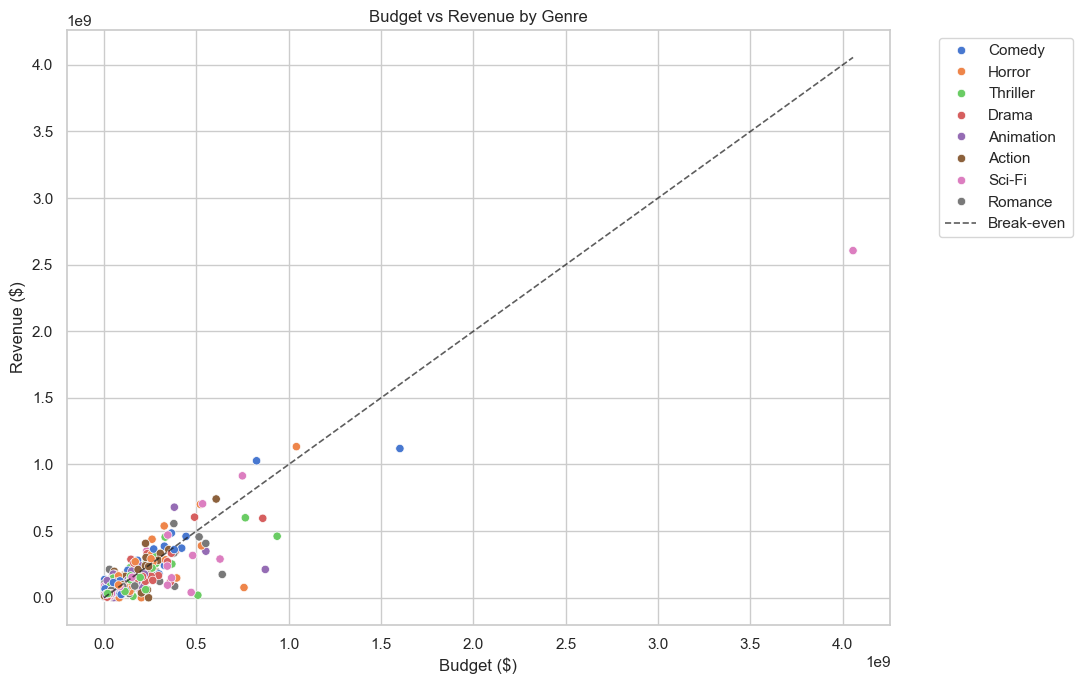

In [15]:
plt.figure(figsize=(11, 7))

# Scatter coloured by genre
sns.scatterplot(
    x='budget', y='revenue', hue='genre', data=df_clean)

# Break-even reference line
break_even = ((df_clean['revenue']) - (df_clean['budget']))
max_val = max(df_clean['budget'].max(), df_clean['revenue'].max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1.2, label='Break-even', alpha=0.7)

plt.title("Budget vs Revenue by Genre")
plt.xlabel("Budget ($)")
plt.ylabel("Revenue ($)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4.4 Correlation Heatmap

**✏️ Your Turn:**
1. Compute the correlation matrix for numeric columns
2. Plot it as an annotated heatmap
3. Which variable has the **strongest linear correlation** with `revenue`?

In [16]:
numeric_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'runtime', 'profit', 'roi']

# YOUR CODE HERE — corr matrix + heatmap (annot=True, fmt='.2f', cmap='coolwarm')
matrix = df_clean['numeric_cols'].corr()
print("Correlation matrix is : ")
print(matrix)

sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Strongest correlate with revenue?
# YOUR ANSWER HERE

KeyError: 'numeric_cols'

### 4.5 Average Revenue by Genre

**✏️ Your Turn:** Plot a horizontal bar chart of mean revenue by genre, sorted highest to lowest.

In [ ]:
genre_revenue = # YOUR CODE HERE  (groupby genre, mean revenue, sort_values)

# YOUR CODE HERE — horizontal bar chart

plt.title("Average Revenue by Genre")
plt.xlabel("Average Revenue ($)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

### 4.6 Trend Over Time

**✏️ Your Turn:** Plot a line chart of **average budget per year** for movies released from 1990 onwards.

In [ ]:
yearly_budget = df_clean[df_clean['release_year'] >= 1990].groupby('release_year')['budget'].mean()

# YOUR CODE HERE — line chart

plt.title("Average Movie Budget by Year (1990–present)")
plt.xlabel("Year")
plt.ylabel("Average Budget ($)")
plt.tight_layout()
plt.show()

---
## Section 5: Inferential Statistics 📐

### 5.1 Z-Scores

**✏️ Your Turn:**
1. Calculate the **mean** and **std** of `vote_average`
2. Compute the **z-score** for a movie rated 8.5
3. Interpret it — is this rating unusually high?

In [ ]:
# 1. Mean and std
mean_vote = # YOUR CODE HERE
std_vote  = # YOUR CODE HERE
print(f"Mean: {mean_vote:.3f} | Std: {std_vote:.3f}")

# 2. Z-score for 8.5
z = # YOUR CODE HERE
print(f"Z-score for 8.5: {z:.2f}")

# 3. Interpretation:
# YOUR ANSWER HERE

### 5.2 Confidence Interval

**✏️ Your Turn:** Calculate a **95% confidence interval** for the true mean `vote_average`.

$$CI = \bar{x} \pm 1.96 \cdot \frac{s}{\sqrt{n}}$$

In [ ]:
n      = len(df_clean['vote_average'])
z_star = 1.96

margin_of_error = # YOUR CODE HERE
ci_lower        = # YOUR CODE HERE
ci_upper        = # YOUR CODE HERE

print(f"Sample size: {n}")
print(f"95% CI: ({ci_lower:.3f}, {ci_upper:.3f})")
print(f"Interpretation: We are 95% confident the true mean vote average lies between {ci_lower:.2f} and {ci_upper:.2f}")

### 5.3 Hypothesis Test

**Scenario:** A producer claims their studio's movies average a rating **above 6.5**.

**✏️ Your Turn:** Run a one-sample t-test at α = 0.05:
- H₀: μ ≤ 6.5
- H₁: μ > 6.5

Write your conclusion in plain English.


In [ ]:
t_stat, p_value = stats.ttest_1samp(
    df_clean['vote_average'],
    popmean=6.5,
    alternative='greater'
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

# Do we reject H0? Write your conclusion:
# YOUR ANSWER HERE

---
## Section 6: Linear Regression 📈

### 6.1 Simple Linear Regression — Budget → Revenue

**✏️ Your Turn:**
1. Define `X` (budget) and `y` (revenue)
2. Split into **80/20 train/test sets** (`random_state=42`)
3. Fit a `LinearRegression` model
4. Print slope, intercept, and R² on both sets

In [ ]:
# 1. Features and target
X = 
y = 

# 2. Train/test split
X_train, X_test, y_train, y_test = # YOUR CODE HERE

# 3. Fit
simple_model = LinearRegression()
# YOUR CODE HERE

# 4. Results
print(f"Intercept: ${simple_model.intercept_:,.0f}")
print(f"Slope:      {simple_model.coef_[0]:.4f}")
print(f"  → For every $1 increase in budget, predicted revenue increases by ${simple_model.coef_[0]:.2f}")
print()
print(f"R² (train): {simple_model.score(X_train, y_train):.4f}")
print(f"R² (test):  {simple_model.score(X_test, y_test):.4f}")

### 6.2 Visualise the Regression Line

**✏️ Your Turn:** Scatter plot of actual test data with the fitted regression line overlaid.

In [ ]:
y_pred_simple = simple_model.predict(X_test)

plt.figure(figsize=(10, 6))

# Scatter: actual test data
# YOUR CODE HERE

# Line: sorted predictions
X_sorted = X_test.sort_values('budget')
plt.plot(X_sorted, simple_model.predict(X_sorted), color='red', linewidth=2, label='Regression line')

plt.title("Simple Linear Regression: Budget vs Revenue")
plt.xlabel("Budget ($)")
plt.ylabel("Revenue ($)")
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Residual Analysis

**✏️ Your Turn:**
1. Compute residuals (`y_test - y_pred`)
2. Plot a **residual plot** (predicted vs residuals) with a horizontal line at zero
3. Plot a **histogram of residuals**
4. Comment: are residuals randomly scattered?

In [ ]:
residuals = y_test - y_pred_simple

# 1. Residual plot
plt.figure(figsize=(10, 5))
# YOUR CODE HERE
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residual Plot")
plt.xlabel("Predicted Revenue ($)")
plt.ylabel("Residuals ($)")
plt.tight_layout()
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(10, 5))
# YOUR CODE HERE
plt.title("Distribution of Residuals")
plt.xlabel("Residual ($)")
plt.tight_layout()
plt.show()

# Comment — are residuals randomly scattered? Normally distributed?
# YOUR ANSWER HERE

### 6.4 Multiple Linear Regression

**✏️ Your Turn:**
1. Use `['budget', 'popularity', 'vote_count', 'runtime']` as features
2. Fit a new model on the same 80/20 split
3. Compare R² and RMSE against the simple model
4. Print the coefficient table — which features drive revenue most?

In [ ]:
features = ['budget', 'popularity', 'vote_count', 'runtime']
X_multi = df_clean[features]
y_multi = df_clean['revenue']

# Train/test split (random_state=42)
X_train_m, X_test_m, y_train_m, y_test_m = # YOUR CODE HERE

# Fit
multi_model = LinearRegression()
# YOUR CODE HERE

y_pred_multi = multi_model.predict(X_test_m)

# Compare models
r2_simple = r2_score(y_test, y_pred_simple)
r2_multi  = r2_score(y_test_m, y_pred_multi)
rmse_simple = mean_squared_error(y_test, y_pred_simple, squared=False)
rmse_multi  = mean_squared_error(y_test_m, y_pred_multi, squared=False)

print(f"{'':20} {'Simple':>12} {'Multiple':>12}")
print(f"{'R²':20} {r2_simple:>12.4f} {r2_multi:>12.4f}")
print(f"{'RMSE ($)':20} {rmse_simple:>12,.0f} {rmse_multi:>12,.0f}")

# Coefficients
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': multi_model.coef_})
print("\nCoefficients:")
print(coef_df.sort_values('Coefficient', ascending=False).to_string(index=False))

# Which features matter most?
# YOUR ANSWER HERE

### 6.5 Actual vs Predicted

**✏️ Your Turn:** Scatter plot of actual vs predicted revenue for the multiple regression model. Add a perfect-prediction diagonal line.

In [ ]:
plt.figure(figsize=(8, 8))

# Scatter: actual vs predicted
# YOUR CODE HERE

# Perfect prediction line
max_val = max(y_test_m.max(), y_pred_multi.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')

plt.title("Multiple Regression: Actual vs Predicted Revenue")
plt.xlabel("Actual Revenue ($)")
plt.ylabel("Predicted Revenue ($)")
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 7: Synthesis & Reflection

### 7.1 Revenue Predictor Function

**✏️ Your Turn:** Write a function `predict_revenue()` that:
- Accepts `budget`, `popularity`, `vote_count`, `runtime`
- Uses your trained **multiple regression model** to return a revenue prediction
- Formats the result as a dollar string e.g. `"$123,456,789"`
- Raises a `ValueError` if budget is negative

In [ ]:
def predict_revenue(budget, popularity, vote_count, runtime):
    """
    Predict movie revenue using the trained multiple regression model.

    Parameters
    ----------
    budget     : float — production budget in dollars
    popularity : float — popularity score
    vote_count : int   — number of audience votes
    runtime    : float — movie duration in minutes

    Returns
    -------
    str — predicted revenue as a formatted dollar string

    Raises
    ------
    ValueError if budget is negative
    """
    # YOUR CODE HERE
    pass


# Test it!
print(predict_revenue(budget=50_000_000,  popularity=45.0, vote_count=2000, runtime=105))
print(predict_revenue(budget=200_000_000, popularity=80.0, vote_count=5000, runtime=150))

# This should raise a ValueError:
try:
    predict_revenue(budget=-1_000_000, popularity=10, vote_count=100, runtime=90)
except ValueError as e:
    print(f"Caught error: {e}")

### 7.2 Bonus Challenge 🌟

**Stretch goal — only if you have time!**

Write a function `top_roi_by_genre(df, n=3)` that returns a **dictionary** mapping each genre to a list of its top `n` movie titles by ROI. Use a loop or dictionary comprehension.

In [ ]:
def top_roi_by_genre(df, n=3):
    """Returns {genre: [top n titles by ROI]} for all genres."""
    # YOUR CODE HERE
    pass

result = top_roi_by_genre(df_clean, n=3)
for genre, titles in result.items():
    print(f"{genre}: {titles}")

### 7.3 Final Reflection ✍️

**Double-click this cell to edit and write your answers.**

**1. Statistics:** What was the most surprising finding in the data?

*Your answer here*

**2. Regression:** What are the limitations of using linear regression to predict movie revenue? What other factors might matter that aren't in this dataset?

*Your answer here*

**3. Python:** Which Phase 1 Python concept did you find most useful in this lab, and why?

*Your answer here*

**4. Next Steps:** If you were to continue this analysis, what would you explore next?

*Your answer here*

---

## 🏁 You've Completed the Phase 1 Capstone Lab!

| Area | What You Practiced |
|---|---|
| 🐍 Python | Variables, data types, loops, comprehensions, data structures |
| 🐼 Pandas | Loading, cleaning, groupby, filtering, sorting |
| 📊 Visualization | Histograms, boxplots, scatter plots, heatmaps, bar charts, line charts |
| 📐 Statistics | Descriptive stats, z-scores, confidence intervals, hypothesis testing |
| 📈 Regression | Simple & multiple linear regression, residuals, RMSE, R² |

**Well done — on to Phase 2! 🚀**